In [1]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 🧠 Étape 5 : Modélisation (Machine Learning & Deep Learning) (Squelette Étudiant)

Cette étape correspond au cinquième chapitre du cours. L'objectif est d'implémenter d'une part un modèle de Machine Learning tabulaire (ex: RandomForest) et d'autre part un réseau de neurones convolutif (CNN) sous TensorFlow pour traiter des images ou signaux complexes.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Activation de l'auto-rechargement des modules personnalisés de 'src/'
%load_ext autoreload
%autoreload 2

# Configuration de l'affichage Pandas
pd.set_option('display.max_columns', None)

# Ajout du dossier racine pour les imports locaux
sys.path.append(os.path.abspath(os.path.join('..')))
import src.train_models as tm

print("[INFO] Environnement configuré et modules chargés avec succès.")

[INFO] Environnement configuré et modules chargés avec succès.


### 2. Chargement et découpage des données enrichies à l'étape EDA

In [3]:
# Chargement du dataset enrichi lors de l'étape EDA
df_final = pd.read_csv("../data/processed/football_final_features.csv")
print(f"[INFO] Dataset de modélisation chargé : {df_final.shape[0]} joueurs, {df_final.shape[1]} features.")

# Découpage des matrices (Train: 80% / Test: 20%) et récupération des types de colonnes
df_train, df_test, df_scouting, X_train, X_test, X_scouting, y_train, y_test, num_cols, cat_cols = tm.prepare_data(df_final)
print(f" -> Taille du jeu d'entraînement : {X_train.shape[0]} joueurs")
print(f" -> Taille du jeu de test : {X_test.shape[0]} joueurs")

# Construction du préprocesseur standardisé via notre module src
preprocessor = tm.build_preprocessing_pipeline(num_cols, cat_cols)

[INFO] Dataset de modélisation chargé : 28722 joueurs, 35 features.
 -> Taille du jeu d'entraînement : 22441 joueurs
 -> Taille du jeu de test : 5611 joueurs


### 3. BASELINE NAÏVE (Demande du template Quarto)

In [4]:
from sklearn.pipeline import Pipeline

# La baseline prédit de manière constante la valeur moyenne constatée sur le Train
y_pred_baseline = np.full(shape=y_test.shape, fill_value=y_train.mean())
mae_base, rmse_base, r2_base = tm.evaluate_predictions(y_test, y_pred_baseline)

print("\n" + "="*40)
print("--- RÉSULTATS DE LA BASELINE NAÏVE ---")
print("="*40)
print(f"MAE (Erreur Moyenne) : {mae_base:,.2f} €")
print(f"RMSE (Pénalité Écarts) : {rmse_base:,.2f} €")
print(f"R² Score : {r2_base:.4f} (0%)")


--- RÉSULTATS DE LA BASELINE NAÏVE ---
MAE (Erreur Moyenne) : 1,803,575.85 €
RMSE (Pénalité Écarts) : 6,878,765.61 €
R² Score : -0.0003 (0%)


### 4. MODÈLE 1 - RANDOM FOREST REGRESSOR

In [5]:
from sklearn.ensemble import RandomForestRegressor

# Assemblage du pipeline global Prétraitement + Algorithme
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1))
])

print("\n[INFO] Entraînement du modèle Random Forest en cours...")
rf_pipeline.fit(X_train, y_train)

# Évaluation du modèle Random Forest
y_pred_rf = rf_pipeline.predict(X_test)
mae_rf, rmse_rf, r2_rf = tm.evaluate_predictions(y_test, y_pred_rf)

print("\n" + "="*40)
print("--- RÉSULTATS RANDOM FOREST ---")
print("="*40)
print(f"MAE (Erreur Moyenne) : {mae_rf:,.2f} €")
print(f"RMSE (Pénalité Écarts) : {rmse_rf:,.2f} €")
print(f"R² Score : {r2_rf:.4f} ({r2_rf*100:.1f}%)")


[INFO] Entraînement du modèle Random Forest en cours...

--- RÉSULTATS RANDOM FOREST ---
MAE (Erreur Moyenne) : 1,491,583.26 €
RMSE (Pénalité Écarts) : 5,768,923.92 €
R² Score : 0.5280 (52.8%)


### 5. MODÈLE 2 - CHALLENGER XGBOOST REGRESSOR

In [6]:
from xgboost import XGBRegressor

# Assemblage du pipeline Boosting
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
])

print("\n[INFO] Entraînement du modèle Challenger XGBoost en cours...")
xgb_pipeline.fit(X_train, y_train)

# Évaluation du modèle XGBoost
y_pred_xgb = xgb_pipeline.predict(X_test)
mae_xgb, rmse_xgb, r2_xgb = tm.evaluate_predictions(y_test, y_pred_xgb)

print("\n" + "="*40)
print("--- RÉSULTATS CHALLENGER XGBOOST ---")
print("="*40)
print(f"MAE (Erreur Moyenne) : {mae_xgb:,.2f} €")
print(f"RMSE (Pénalité Écarts) : {rmse_xgb:,.2f} €")
print(f"R² Score : {r2_xgb:.4f} ({r2_xgb*100:.1f}%)")


[INFO] Entraînement du modèle Challenger XGBoost en cours...

--- RÉSULTATS CHALLENGER XGBOOST ---
MAE (Erreur Moyenne) : 1,475,077.21 €
RMSE (Pénalité Écarts) : 5,762,268.98 €
R² Score : 0.5444 (54.4%)


### 6. ANALYSE DE L'IMPORTANCE DES VARIABLES (EXPLICABILITÉ)


[INFO] Génération du graphique d'explicabilité (Feature Importance)...


/tmp/ipykernel_35647/3214841740.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')


[SUCCÈS] Graphique d'importance sauvegardé dans : ../report/figures/feature_importance.png


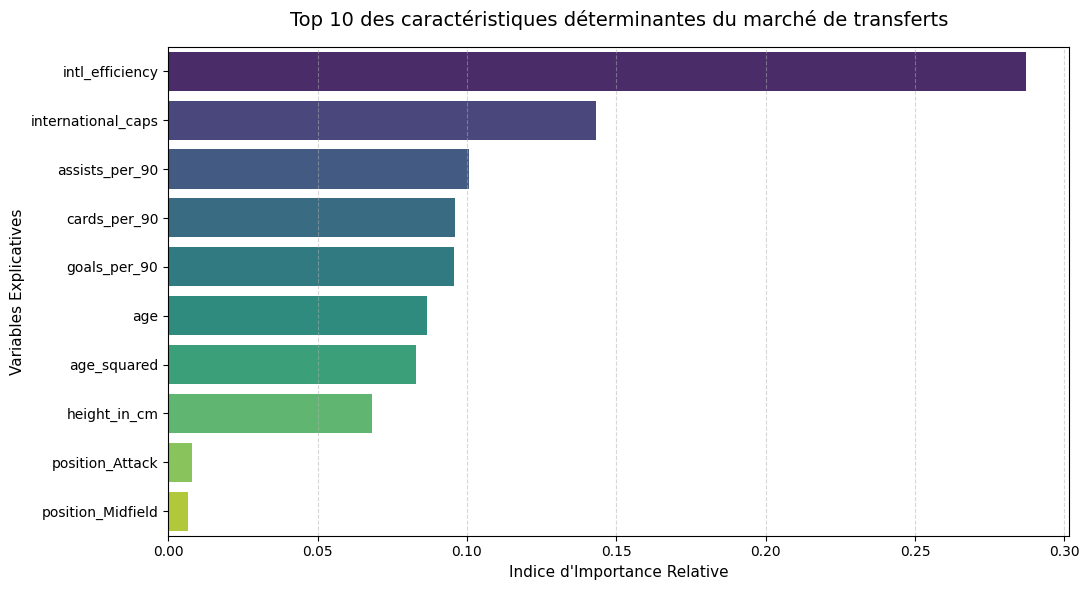

In [7]:
print("\n[INFO] Génération du graphique d'explicabilité (Feature Importance)...")

# Extraction des étiquettes textuelles reconstruites par le One-Hot Encoder
cat_encoder = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
categorical_features_encoded = cat_encoder.get_feature_names_out(cat_cols)
all_features_names = num_cols + list(categorical_features_encoded)

# Récupération des poids attribués par la forêt aléatoire
importances = rf_pipeline.named_steps['regressor'].feature_importances_

# Structuration dans un tableau de données pour extraction du Top 10
df_importance = pd.DataFrame({
    'Feature': all_features_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# Tracé du graphique
plt.figure(figsize=(11, 6))
sns.barplot(data=df_importance, x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 des caractéristiques déterminantes du marché de transferts", fontsize=14, pad=15)
plt.xlabel("Indice d'Importance Relative", fontsize=11)
plt.ylabel("Variables Explicatives", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

# Sauvegarde de la figure pour compilation dynamique dans Quarto
os.makedirs("../reports/figures/", exist_ok=True)
output_fig_path = "../report/figures/feature_importance.png"
plt.savefig(output_fig_path, dpi=300)
print(f"[SUCCÈS] Graphique d'importance sauvegardé dans : {output_fig_path}")
plt.show()